## Ajuste datos experimentales

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import subprocess
import sys
import os
import shutil

from RRAM import Plot_PostProcess as pplt
from pdf2image import convert_from_path

In [2]:
# ruta_raiz = 'C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/'
ruta_raiz = '/Users/antonio_lopez_torres/Documents/GitHub/RRAM_Simulation/'  # Ruta en el mac
sys.path.append(ruta_raiz)

# Ruta proporcionada
ruta_exp_data = ruta_raiz + 'Datos_Experimentales/Ciclos_Experimentales/'
ruta_init_data = ruta_raiz + 'Initial_data/'

In [3]:
# Solicitar la ruta del archivo al usuario
ruta_archivo_set = ruta_exp_data + '/Cycle_p_1000.txt'
ruta_archivo_reset = ruta_exp_data + '/Cycle_n_1000.txt'

# Leer datos del archivo
data_set = np.loadtxt(ruta_archivo_set)
data_reset = np.loadtxt(ruta_archivo_reset)

ruta_init_script = ruta_raiz + 'Init_simulation.py'
ruta_simulation_script = ruta_raiz + 'RRAM_Simulation_exceptions.py'

In [ ]:
# Creo los vectores y luego los combino para generar los sets de datos a probar
I_0 = [2e-3]
ohm_resistence = [1.5, 2, 2.5]
gamma = [6, 7, 8, 9]
E_m = [0.95, 0.9, 0.85, 0.8]
# gamma_drift = [7, 8, 9, 10, 11, 12]

In [5]:
# Generamos la lista de tuplas con la combinación de valores
data = [(v1, v2, v3) for v2 in gamma for v1 in ohm_resistence for v3 in I_0]

print("data:", data)

# Extraemos los valores usando zip
ohm_resistence, gamma, I_0 = zip(*data)

# Convertimos a listas nuevamente
I_0 = list(I_0)
ohm_resistence = list(ohm_resistence)
gamma = list(gamma)

print("ohm_resistence:", ohm_resistence)
print("gamma:", gamma)
print("I_0:", I_0)

data: [(1.5, 6, 0.002), (2, 6, 0.002), (2.5, 6, 0.002), (1.5, 7, 0.002), (2, 7, 0.002), (2.5, 7, 0.002), (1.5, 8, 0.002), (2, 8, 0.002), (2.5, 8, 0.002), (1.5, 9, 0.002), (2, 9, 0.002), (2.5, 9, 0.002)]
ohm_resistence: [1.5, 2, 2.5, 1.5, 2, 2.5, 1.5, 2, 2.5, 1.5, 2, 2.5]
gamma: [6, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 9]
I_0: [0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002]


In [6]:
# Guardo los datos en un archivo pkl
import pickle

with open(ruta_init_data + 'I_0.pkl', 'wb') as f:
    pickle.dump(I_0, f)

with open(ruta_init_data + 'ohm_resistence.pkl', 'wb') as f:
    pickle.dump(ohm_resistence, f)

# with open(ruta_init_data + 'drift_coefficient.pkl', 'wb') as f:
#     pickle.dump(gamma_drift, f)

with open(ruta_init_data + 'gamma.pkl', 'wb') as f:
    pickle.dump(gamma, f)

In [7]:
# LLamo al script de configuracion que genera los archivos de configuracion
subprocess.run(["python", ruta_init_script, ruta_init_data, str(len(ohm_resistence))])

Ruta de los archivos de datos: /Users/antonio_lopez_torres/Documents/GitHub/RRAM_Simulation/Initial_data/
El número de simulaciones es: 12


CompletedProcess(args=['python', '/Users/antonio_lopez_torres/Documents/GitHub/RRAM_Simulation/Init_simulation.py', '/Users/antonio_lopez_torres/Documents/GitHub/RRAM_Simulation/Initial_data/', '12'], returncode=0)

In [8]:
# Defino la carpeta donde se guardan los datos iniciales de la simulación
carpeta_results = 'Results'

simulation_path = os.path.join(carpeta_results)

# Verifica si la carpeta existe
if os.path.exists(simulation_path):
    # Elimina la carpeta y su contenido
    shutil.rmtree(simulation_path)
    # crea la carpeta
    os.makedirs(simulation_path)

guardar_datos = False

for num_simulacion in range(len(ohm_resistence)):
    # Llamo al script de simuluacion
    subprocess.run(["python", ruta_simulation_script, str(num_simulacion), str(guardar_datos)])

El número de simulación es: 0
Se guardan las configuraciones: False

Simulación 1

El paso temporal es de 0.001 s
El paso del potencial es de 0.00014 s

El valor de la resistencia de cada casilla es:  1.5
El valor de gamma es:  6
El valor de resistencia termica no percola es:  5.0
El valor de resistencia termica percola es:  500.0
El valor de I_0 es:  0.002

 Comienza la primera parte del set


  0%|          | 0/7858 [00:00<?, ?it/s]


Se ha superado el voltaje de ruptura en la iteracion:  7858
Voltaje final set 1.10012 en el tiempo  7.857 

Voltaje inicial sp set 1.10012

 Comienza la segunda parte del set


100%|██████████| 7858/7858 [00:22<00:00, 343.36it/s]



 Comienza la primera parte del reset


...


 Comienza la primera parte del reset


  0%|          | 0/10000 [00:00<?, ?it/s]


 Comienza la segunda parte del reset


100%|██████████| 10000/10000 [00:17<00:00, 560.57it/s]


Todos los archivos CSV se han combinado y guardado exitosamente.


In [9]:
# num_simulation = 0

# set_simulation_path = os.path.join(carpeta_results, f'simulation_{num_simulation}/set/')
# os.makedirs(set_simulation_path, exist_ok=True)
#
# reset_simulation_path = os.path.join(carpeta_results, f'simulation_{num_simulation}/reset/')
# os.makedirs(reset_simulation_path, exist_ok=True)

In [10]:
# # region Representar datos
# data_path_pp_set = set_simulation_path + f'resultados_pp_set_{num_simulation}.csv'
# data_path_sp_set = set_simulation_path + f'resultados_sp_set_{num_simulation}.csv'
# data_path_pp_reset = reset_simulation_path + f'resultados_pp_reset_{num_simulation}.csv'
# data_path_sp_reset = reset_simulation_path + f'resultados_sp_reset_{num_simulation}.csv'

# df_pset = pd.read_csv(data_path_pp_set, dtype=float)
# df_sset = pd.read_csv(data_path_sp_set, dtype=float)
# df_preset = pd.read_csv(data_path_pp_reset, dtype=float)
# df_sreset = pd.read_csv(data_path_sp_reset, dtype=float)

# global_tittle = 'Intensidad vs Voltaje'

# save_path = simulation_path + f'Figures/Intensidad_Voltaje_simulation_{num_simulation}'

# i_ps = np.array(df_pset['Temperatura [K]'])
# i_ss = np.array(df_sset['Temperatura [K]'])
# i_pr = np.array(df_preset['Temperatura [K]'])
# i_sr = np.array(df_sreset['Temperatura [K]'])
# v_ps = np.array(df_pset['Voltaje [V]'])
# v_ss = np.array(df_sset['Voltaje [V]'])
# v_pr = np.array(df_preset['Voltaje [V]'])
# v_sr = np.array(df_sreset['Voltaje [V]'])

# fig, axes = plt.subplots()

# pplt.config_ax(axes)

# axes.set_xlabel('Voltaje [V]')
# axes.set_ylabel('Temperatura [K]')
# # axes.set_yscale('log')

# axes.set_title(global_tittle, fontsize=18, pad=15)

# axes.plot(v_ps, i_ps, color='blue', label='Primera parte Set')
# axes.plot(v_ss, i_ss, color='red', label='Segunda parte Set')
# axes.plot(v_pr, i_pr, color='green', label='Primera parte Reset')
# axes.plot(v_sr, i_sr, color='pink', label='Segunda parte Reset')

# plt.legend()

# # Ruta proporcionada
# ruta_exp_data = ruta_raiz + 'Datos_Experimentales/Ciclos_Experimentales'
# ruta_archivo_set = ruta_exp_data + '/Cycle_p_1000.txt'
# ruta_archivo_reset = ruta_exp_data + '/Cycle_n_1000.txt'

# # Leer datos del archivo
# data_set = np.loadtxt(ruta_archivo_set)
# data_reset = np.loadtxt(ruta_archivo_reset)
# # Asumimos que los datos están en dos columnas: x e y

# x_set = data_set[:, 0]
# y_set = data_set[:, 1]

# # Data reset
# x_reset = data_reset[:, 0]
# y_reset = abs(data_reset[:, 1])

# # Añado los valores de las variables que estoy cambiando, para eso tengo q ver dentro de la carpeta de init_data el nombre de cada documento, si el nombre conindice con una variable del diccionario, añado el valor que está tomando en la simulación en la representación

# # Leer los valores de las variables desde los archivos en Initial_data
# init_data_path = 'Initial_data'
# variables = {}

# for filename in os.listdir(init_data_path):
#     if filename.endswith('.pkl'):
#         variable_name = filename.split('.')[0]
#         with open(os.path.join(init_data_path, filename), 'rb') as f:
#             variables[variable_name] = pickle.load(f)

# # Crear el subtítulo con los valores de las variables
# subtitle = '\n'.join([f'{variable_name} = {value[num_simulation]}' for variable_name, value in variables.items()])
# fig.suptitle(subtitle, fontsize=10, y=1.05)  # Ajusta el valor de y según sea necesario

# # Crear la gráfica scatter
# # axes.plot(x_set, y_set, 'black', label='Set experimental')
# # axes.plot(x_reset, y_reset, 'black', label='Reset experimental')
# # fig.savefig(save_path + '.pdf', bbox_inches='tight')

Results/FiguresIntensidad_Voltaje_simulation_0.pdf


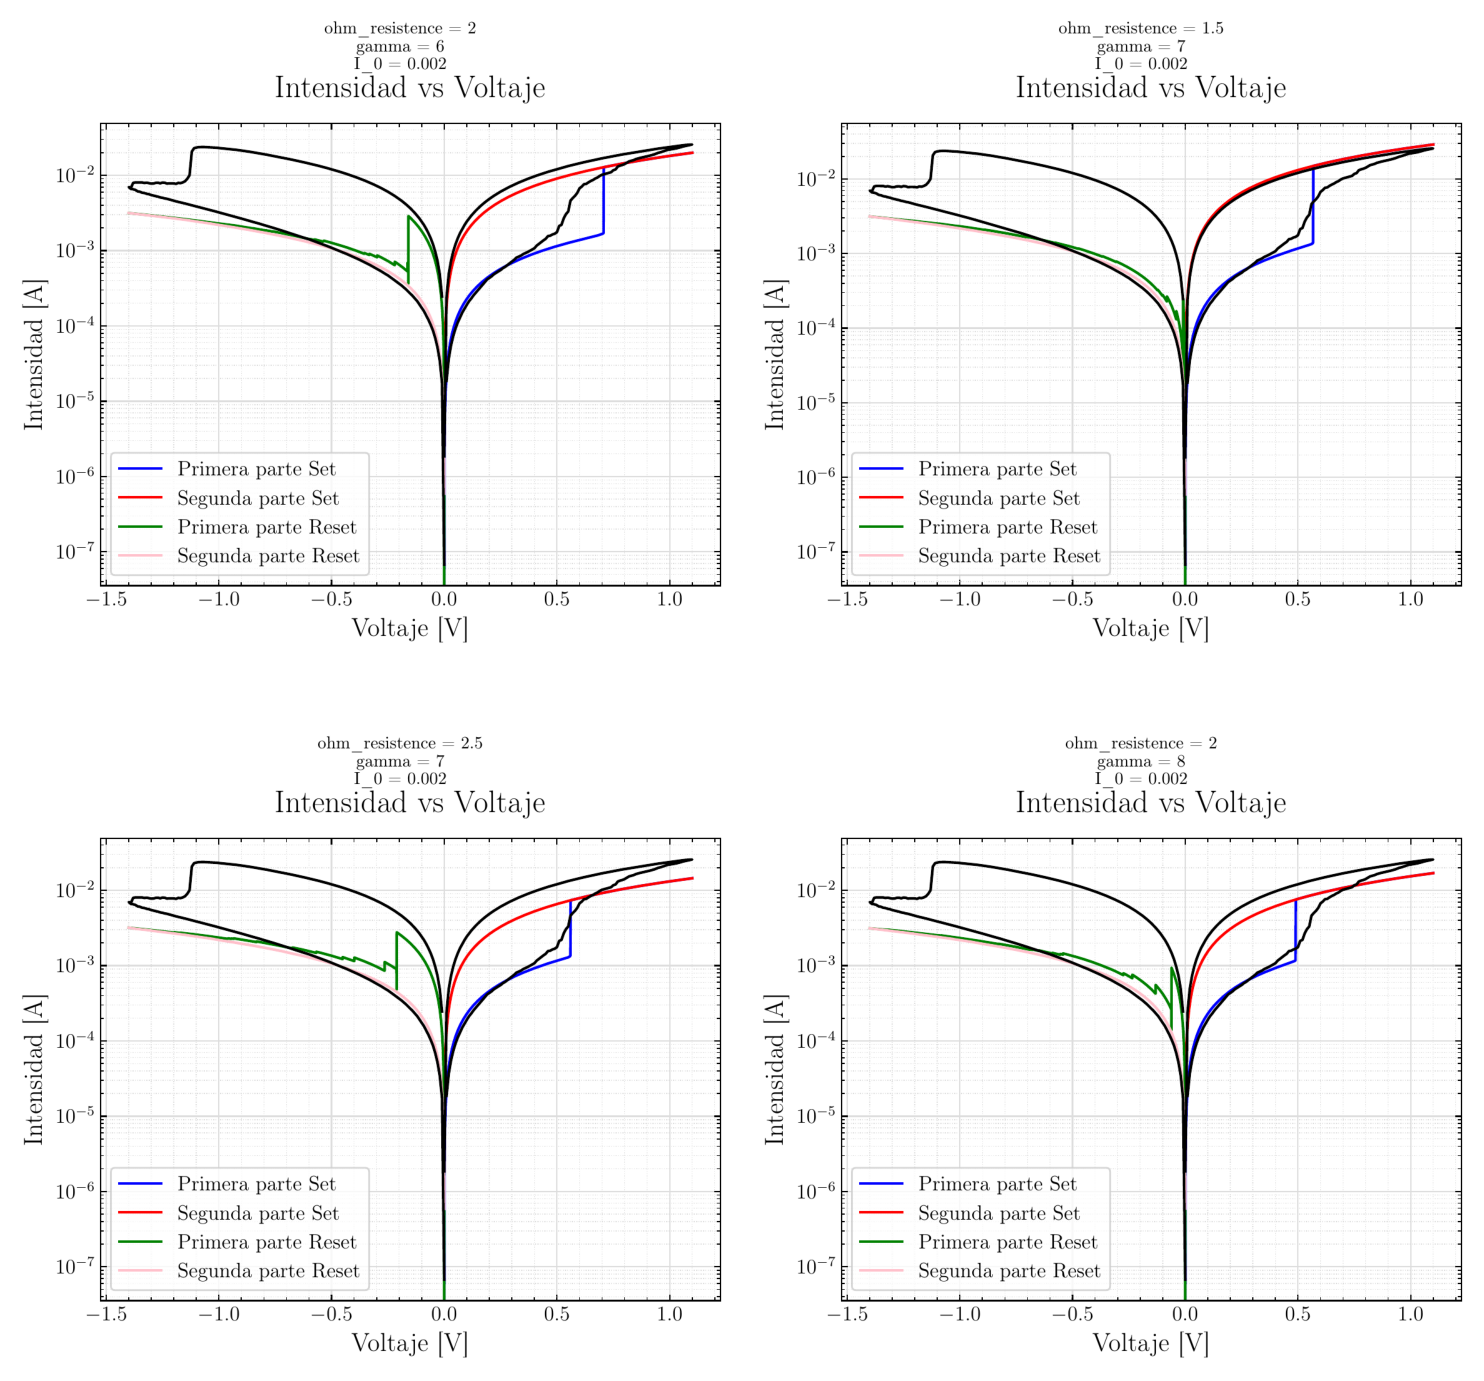

In [11]:
# Convertir PDFs a imágenes

print(f'Results/FiguresIntensidad_Voltaje_simulation_{0}.pdf')

# Tomar la primera página
imagenes = [convert_from_path(f"Results/Figures/Intensidad_Voltaje_simulation_{i}.pdf")[0] for i in (2, 4, 6, 8)]

# Crear el mosaico
fig, axs = plt.subplots(2, 2, figsize=(15, 15))

# Mostrar cada imagen en el mosaico
for ax, img in zip(axs.flatten(), imagenes):
    ax.imshow(img)
    ax.axis("off")  # Ocultar ejes

plt.tight_layout()
plt.savefig("Intensidad-Voltaje_Resistencia_2.5_I_0_5e-4.png")
plt.show()